# Assignment 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
plt.style.use('dark_background')

# Assignment 2

## Exercise 1: Initial Setup and computing the cluster centre and radii

## 1.1

(to delete later for conservative space in notebook)

(a) First, load in the stars data as shown in Assignment 1. Then load the list of clusters in assignment2_clusters.dat
into a pandas Series object. To assign a cluster, write down the last four digits of your StudentID 𝑘, and compute
your unique cluster ID using those numbers and the length of the list you loaded from
assignment2_clusters.dat :

cluster_index = k % len(assigment2_clusters)

cluster_name = assigment2_clusters.iloc[cluster_index]

Here, the % symbol computes the modulo (remainder after dividing k by the length of the cluster dataframe). In your
notebook, be sure you note down k, the cluster index and the name of the cluster you will be working with.

In [43]:
gaia_file = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/gaia_data.fits'
new_clusters = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/assignment2_clusters.dat'

# code given for previous assignment
dr3stars = fits.open(gaia_file)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()

In [44]:
# for the cluster 
new_cluster_series = pd.read_csv(new_clusters, delimiter=',')['0']


In [45]:
new_cluster_series

0        Alessi_43
1           BH_202
2            BH_99
3      Berkeley_17
4      Berkeley_18
          ...     
133       UBC_1004
134        UBC_106
135        UBC_246
136        UBC_334
137         UFMG_2
Name: 0, Length: 138, dtype: object

In [46]:
k = 7943
cluster_index = k % len(new_cluster_series)
cluster_name = new_cluster_series.loc[cluster_index]


In [47]:
print(cluster_index, cluster_name)

77 NGC_2658


**Noting:** 
- Last four digits of my Student ID number ($k$): 7943
- cluster index = 77
- cluster name = NGC_2658

In [66]:
my_cluster = stars[stars['Name']=='NGC_2658'].copy()
my_cluster

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
439834,NGC_2658,4600,5639494885187879296,0,0.479078,130.941849,0.065652,-32.608163,0.082868,254.556687,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
439835,NGC_2658,4600,5639494889487691008,1,0.962717,130.934933,0.012832,-32.613708,0.016555,254.557497,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
439836,NGC_2658,4600,5639494958207185920,1,0.819467,130.896583,0.022477,-32.623757,0.026645,254.545560,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
439837,NGC_2658,4600,5639494889487693440,0,0.445394,130.934166,0.032503,-32.616944,0.040286,254.559670,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
439838,NGC_2658,4600,5639494919547578496,0,0.394955,130.882309,0.097748,-32.631417,0.119727,254.544235,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440674,NGC_2658,4600,5639416819859780864,0,0.381327,130.538513,0.172429,-32.564467,0.223082,254.312876,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
440675,NGC_2658,4600,5639416927234441984,0,0.375669,130.478980,0.151505,-32.578651,0.178068,254.293420,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
440676,NGC_2658,4600,5639418679588354048,0,0.336513,130.309571,0.016393,-32.600227,0.022382,254.223263,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
440677,NGC_2658,4600,5639420225776518400,0,0.337950,130.436671,0.011018,-32.533539,0.014236,254.235618,...,5.0,13.417866,0.061371,24.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0


## 1.2

Use the functions provided in the helper Python script to compute a cluster centre on the sphere and angular
separations for each star from that centre. From there, you can compute the projected radius in arcmin for each star:

$$ R_i = 60 \times \theta_i \times \frac{180}{\pi} $$
where $$ \theta_i = \text{angular\_separation(•)} $$

In [72]:
# obviously taken from the assignment2.py
def spherical_center(ra_deg, dec_deg):
    """
    Compute a centre on the celestial sphere by averaging unit vectors.

    Parameters
    ----------
    ra_deg, dec_deg : float, float
        The RA and Dec in degrees

    Returns
    -------
    ra0, dec0 : float, float
        The centre RA and Dec in degrees
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)
    r = np.sqrt(xm**2 + ym**2 + zm**2)
    xm, ym, zm = xm/r, ym/r, zm/r

    dec0 = np.arcsin(zm)
    ra0 = np.arctan2(ym, xm) % (2*np.pi)

    return np.rad2deg(ra0), np.rad2deg(dec0)

# also from assignment2.py
def angular_separation(ra_deg, dec_deg, ra0_deg, dec0_deg):
    """
    Compute the Great-circle angular separation in radians.

    Parameters
    ----------
    ra_deg, dec_deg : iterable, iterable
        RA and Dec values in degrees of an iterable of stars

    ra0_deg, dec0_deg : float, float
        RA and Dec values of the cluster centre

    Returns
    -------
    ang_sep : float
        The angular separation in radians
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    cosang = np.sin(dec)*np.sin(dec0) + np.cos(dec)*np.cos(dec0)*np.cos(ra - ra0)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang_sep = np.arccos(cosang)
    return ang_sep


# compute centre using function and print coordinates
sph_center = spherical_center(ra_deg = my_cluster['RAdeg'], 
                              dec_deg = my_cluster['DEdeg'])
print(f'cluster centre coordinates: ' 
      f'RA = {sph_center[0]:.3f} deg, '
      f'Dec = {sph_center[1]:.3f} deg')

# compute angular separation iterating through cluster dataframe
# and add new column of separations to dataframe for each star
ang_seps = []
for i in range(len(my_cluster)): 
    ang_sep = angular_separation(ra_deg = my_cluster.iloc[i]['RAdeg'], 
                                dec_deg = my_cluster.iloc[i]['DEdeg'], 
                                ra0_deg = sph_center[0], 
                                dec0_deg = sph_center[1])
    ang_seps.append(ang_sep)

my_cluster['ang_seps'] = ang_seps

print('angular separations series: ')
my_cluster['ang_seps']

cluster centre coordinates: RA = 130.869 deg, Dec = -32.645 deg
angular separations series: 


439834    0.001250
439835    0.001113
439836    0.000551
439837    0.001076
439838    0.000310
            ...   
440674    0.005061
440675    0.005852
440676    0.008262
440677    0.006651
440678    0.003159
Name: ang_seps, Length: 845, dtype: float64

#### 1.2.i: *Make a scatter plot of RA vs Dec with the center marked*

Text(0.5, 1.0, 'DEC vs. RA Scatter Plot')

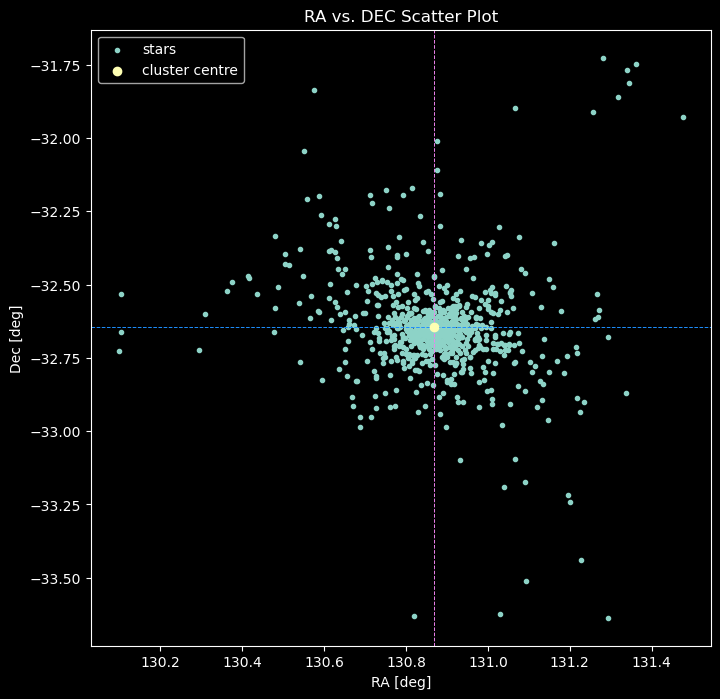

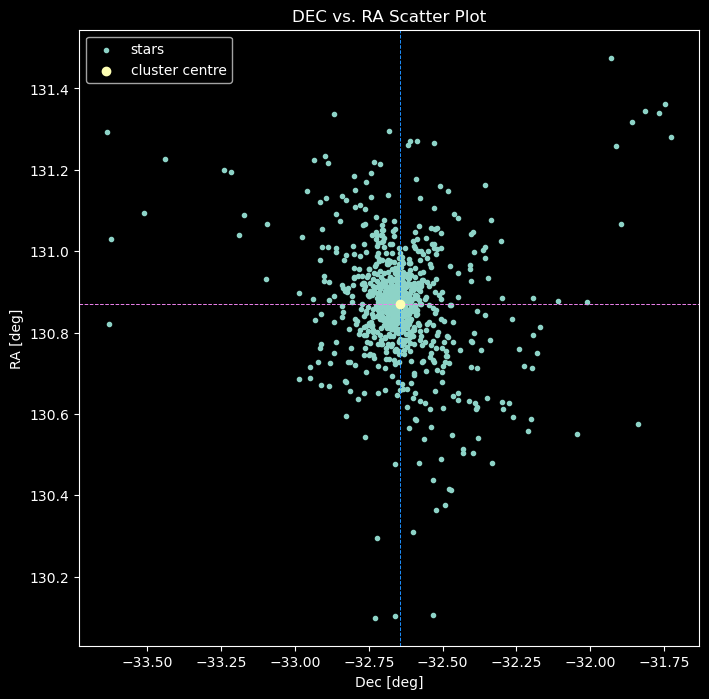

In [86]:
plt.figure(figsize = (8,8))
plt.scatter(my_cluster['RAdeg'], my_cluster['DEdeg'], marker = '.', label = 'stars')
plt.axvline(sph_center[0], ls = 'dashed', lw = 0.7, color = 'violet')
plt.axhline(sph_center[1], ls = 'dashed', lw = 0.7, color = 'dodgerblue')
plt.scatter(sph_center[0], sph_center[1], label = 'cluster centre', zorder=3)
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')
plt.legend()
plt.title('RA vs. DEC Scatter Plot')

plt.figure(figsize = (8,8))
plt.scatter(my_cluster['DEdeg'], my_cluster['RAdeg'], marker = '.', label = 'stars')
plt.axhline(sph_center[0], ls = 'dashed', lw = 0.7, color = 'violet')
plt.axvline(sph_center[1], ls = 'dashed', lw = 0.7, color = 'dodgerblue')
plt.scatter(sph_center[1], sph_center[0], label = 'cluster centre', zorder=3)
plt.ylabel('RA [deg]')
plt.xlabel('Dec [deg]')
plt.legend()
plt.title('DEC vs. RA Scatter Plot')

#### 1.2.ii *Comment on any structure you see in the scatter plot and how this might affect a radially binned profile.*

It seems that the cluster is generally pretty uniformly distributed in structure. However I do see a little bit of prominence on the left side of the cluster (which is also evident with the stars at the edge (<130.2 deg))